## Process Data Tables from Laserchron for Analysis

In [32]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cmcrameri.cm as cmc

from geoscripts.dz import dz

In [33]:
# Write function to process Laserchron Excel files
def extract_lchron(path):
    accepted = pd.read_excel(path,skiprows=22,header=None,index_col=0,usecols='A:T')
    cols_combined = accepted.iloc[0] + ' ' + accepted.iloc[1]
    accepted.columns = cols_combined
    accepted.drop(accepted.index[:3],inplace=True)

    rejected = pd.read_excel(path,skiprows=22,header=None,index_col=0,usecols='W:AP')
    rejected.columns = cols_combined
    rejected.drop(rejected.index[:3],inplace=True)

    name = os.path.basename(path).split()[1]

    return(accepted,rejected,name)

In [34]:
# Extract data from Laserchron files
directory = './laserchron_data'
files = os.listdir(directory)
paths = [os.path.join(directory,file) for file in files]

data = [extract_lchron(path) for path in paths]

# Print columns
print(data[0][0].columns)

Index(['U (ppm)', '206Pb 204Pb', 'U/Th  ', '206Pb* 207Pb*', '± 2s (%)',
       '207Pb* 235U', '± 2s (%)', '206Pb* 238U', '± 2s (%)', 'error corr.',
       '206Pb* 238U', '± 2s (Ma)', '207Pb* 235U', '± 2s (Ma)', '206Pb* 207Pb*',
       '± 2s (Ma)', 'Best age (Ma)', '± 2s (Ma)', 'Conc (%)'],
      dtype='object')


In [35]:
# Get location data from field notes
meta_mr = pd.read_csv('field_data/2024_mr_field_samples.csv',index_col=0)

meta_ne = pd.read_excel('field_data/2024_ne_field_samples.xlsx',index_col=0,header=2)
meta_ne.index = meta_ne.index.str.replace('NE240','NEV24-0')
meta_ne.index = meta_ne.index.str.replace('NEV240','NEV24-0')

locations = pd.concat([meta_mr,meta_ne])[['Latitude','Longitude']]
print(locations)

             Latitude  Longitude
MR24-001a   32.351020  -7.939210
MR24-001b   32.351020  -7.939210
MR24-002    32.283420  -8.033810
MR24-003    32.288260  -8.055230
MR24-004    32.301360  -8.075090
MR24-005    32.356480  -8.146250
MR24-006    32.473580  -8.371450
MR24-007    32.038720  -7.985450
MR24-008    32.124980  -8.714180
MR24-009    32.124510  -8.714690
MR24-010    32.026740  -8.520350
MR24-011    31.965820  -8.329220
MR24-012    31.902660  -8.202020
MR24-013    31.901120  -8.203700
MR24-014a   31.852600  -8.174080
MR24-014b   31.852600  -8.174080
MR24-014c   31.852600  -8.174080
MR24-015    31.834530  -8.162410
MR24-016    31.823670  -8.154420
MR24-017    31.717650  -7.913000
MR24-018    31.889070  -7.946660
MR24-019    31.547360  -7.565700
MR24-020    31.547370  -7.565550
MR24-021    31.536300  -7.503940
MR24-023    31.451310  -7.395110
MR24-024    31.259100  -7.399930
MR24-025    32.098550  -5.511070
MR24-026a   32.141590  -5.570550
MR24-026b   32.141590  -5.570550
MR24-027  

In [36]:
# Create DZ objects from data (accepted only initially)
smps = [dz.DZSample(name=sample[2],agedata=sample[0],
                    latlon=(locations.loc[sample[2],'Latitude'],
                            locations.loc[sample[2],'Longitude']),
                            source='Vasey',reported_age='P-Tr') for sample in data]
smps.sort(key=lambda x: x.name)
for smp in smps:
    smp.save()

In [37]:
# Prep data for IsoplotR
output = 'isoplotr/input_data/'
ages_df = pd.DataFrame()
os.makedirs(output,exist_ok=True)
for smp in smps:
    iso_data = smp.agedata.iloc[:,5:10]
    iso_cols = ['75','75_err','68','68_err','rho']
    iso_data.columns = iso_cols
    iso_data.to_csv(output+smp.name+'.csv',index=False)

    # Ages for detritals file
    smp_ages = smp.agedata['Best age (Ma)'].reset_index(drop=True)
    smp_ages.name = smp.name
    ages_df = pd.concat([ages_df,smp_ages],axis=1)


ages_df.to_csv(output+'laserchron_ages.csv',index=False)

<class 'numpy.ndarray'>


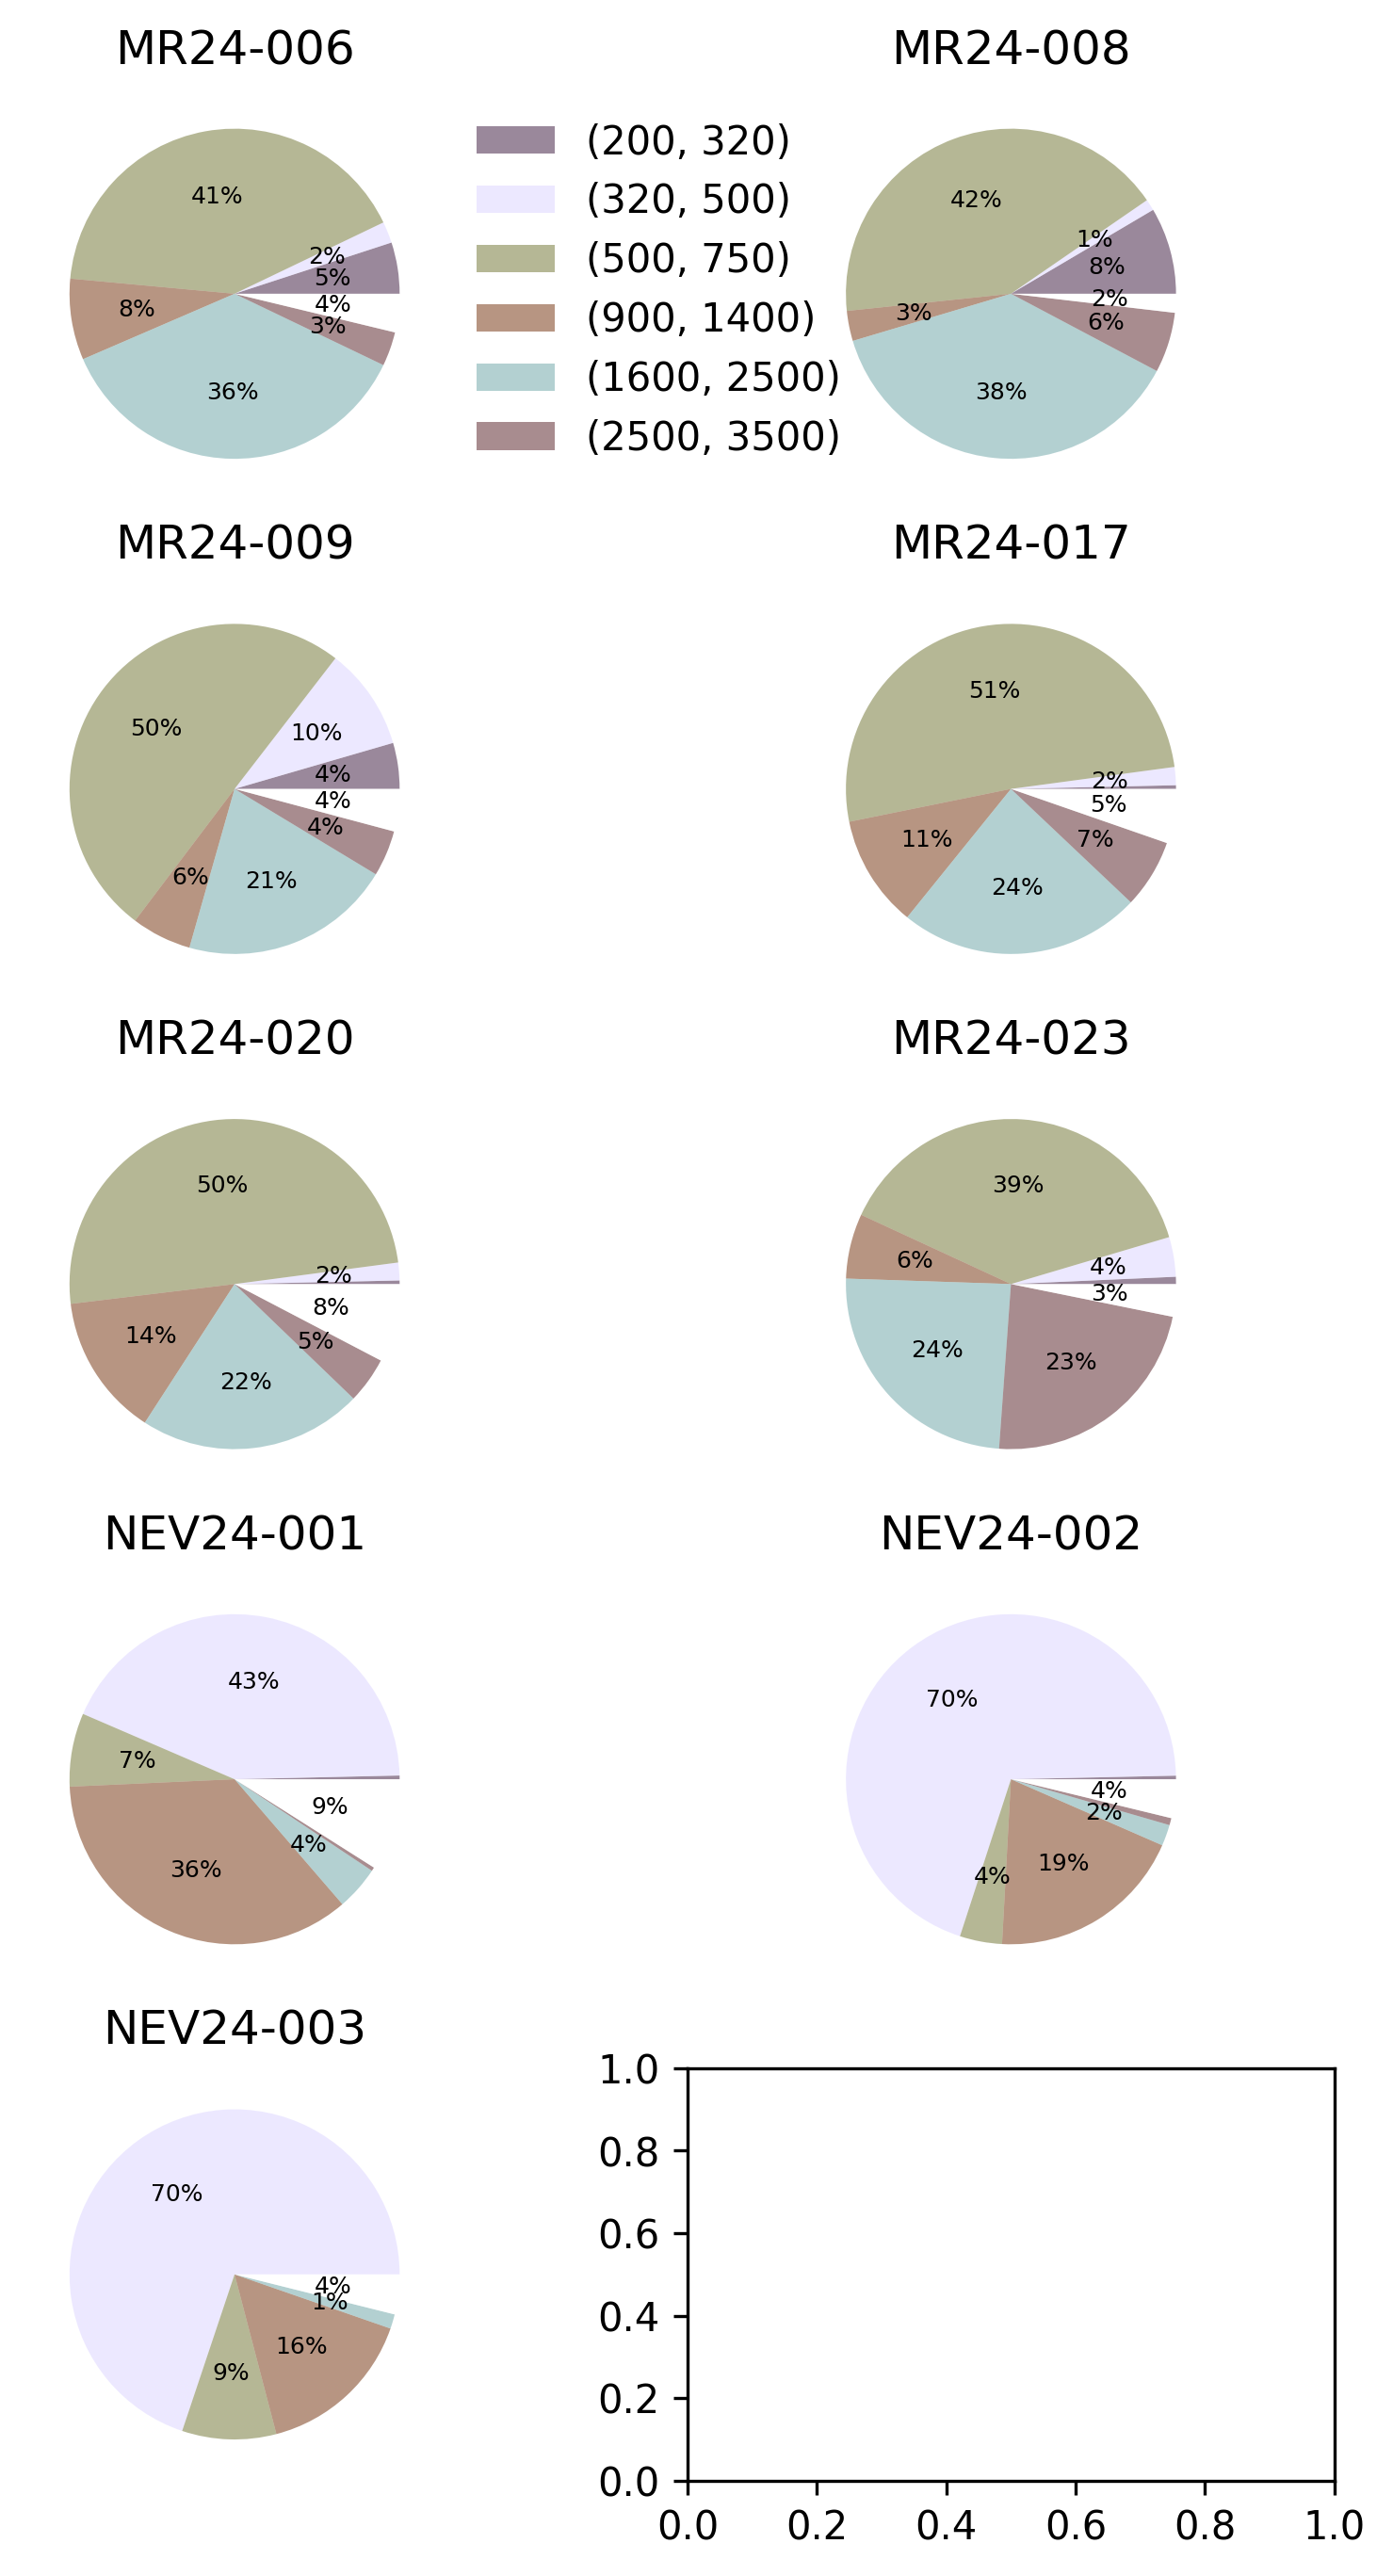

In [38]:
# Plot pie charts using spans
spans = [(200,320),(320,500),(500,750),(900,1400),(1600,2500),(2500,3500)]
cmap = cmc.glasgowS
colors = cmap.colors
print(type(colors))

fig,axs = plt.subplots(5,2,figsize=(6.5,11),dpi=300)

for k,smp in enumerate(smps):
    ax = axs.flat[k]
    ax.set_title(smp.name)
    smp.bestage=smp.agedata['Best age (Ma)'].astype(float)
    smp.pie(ax=ax,spans=spans,textprops={'fontsize':6},colors=colors)

axs.flat[0].legend(labels=spans)

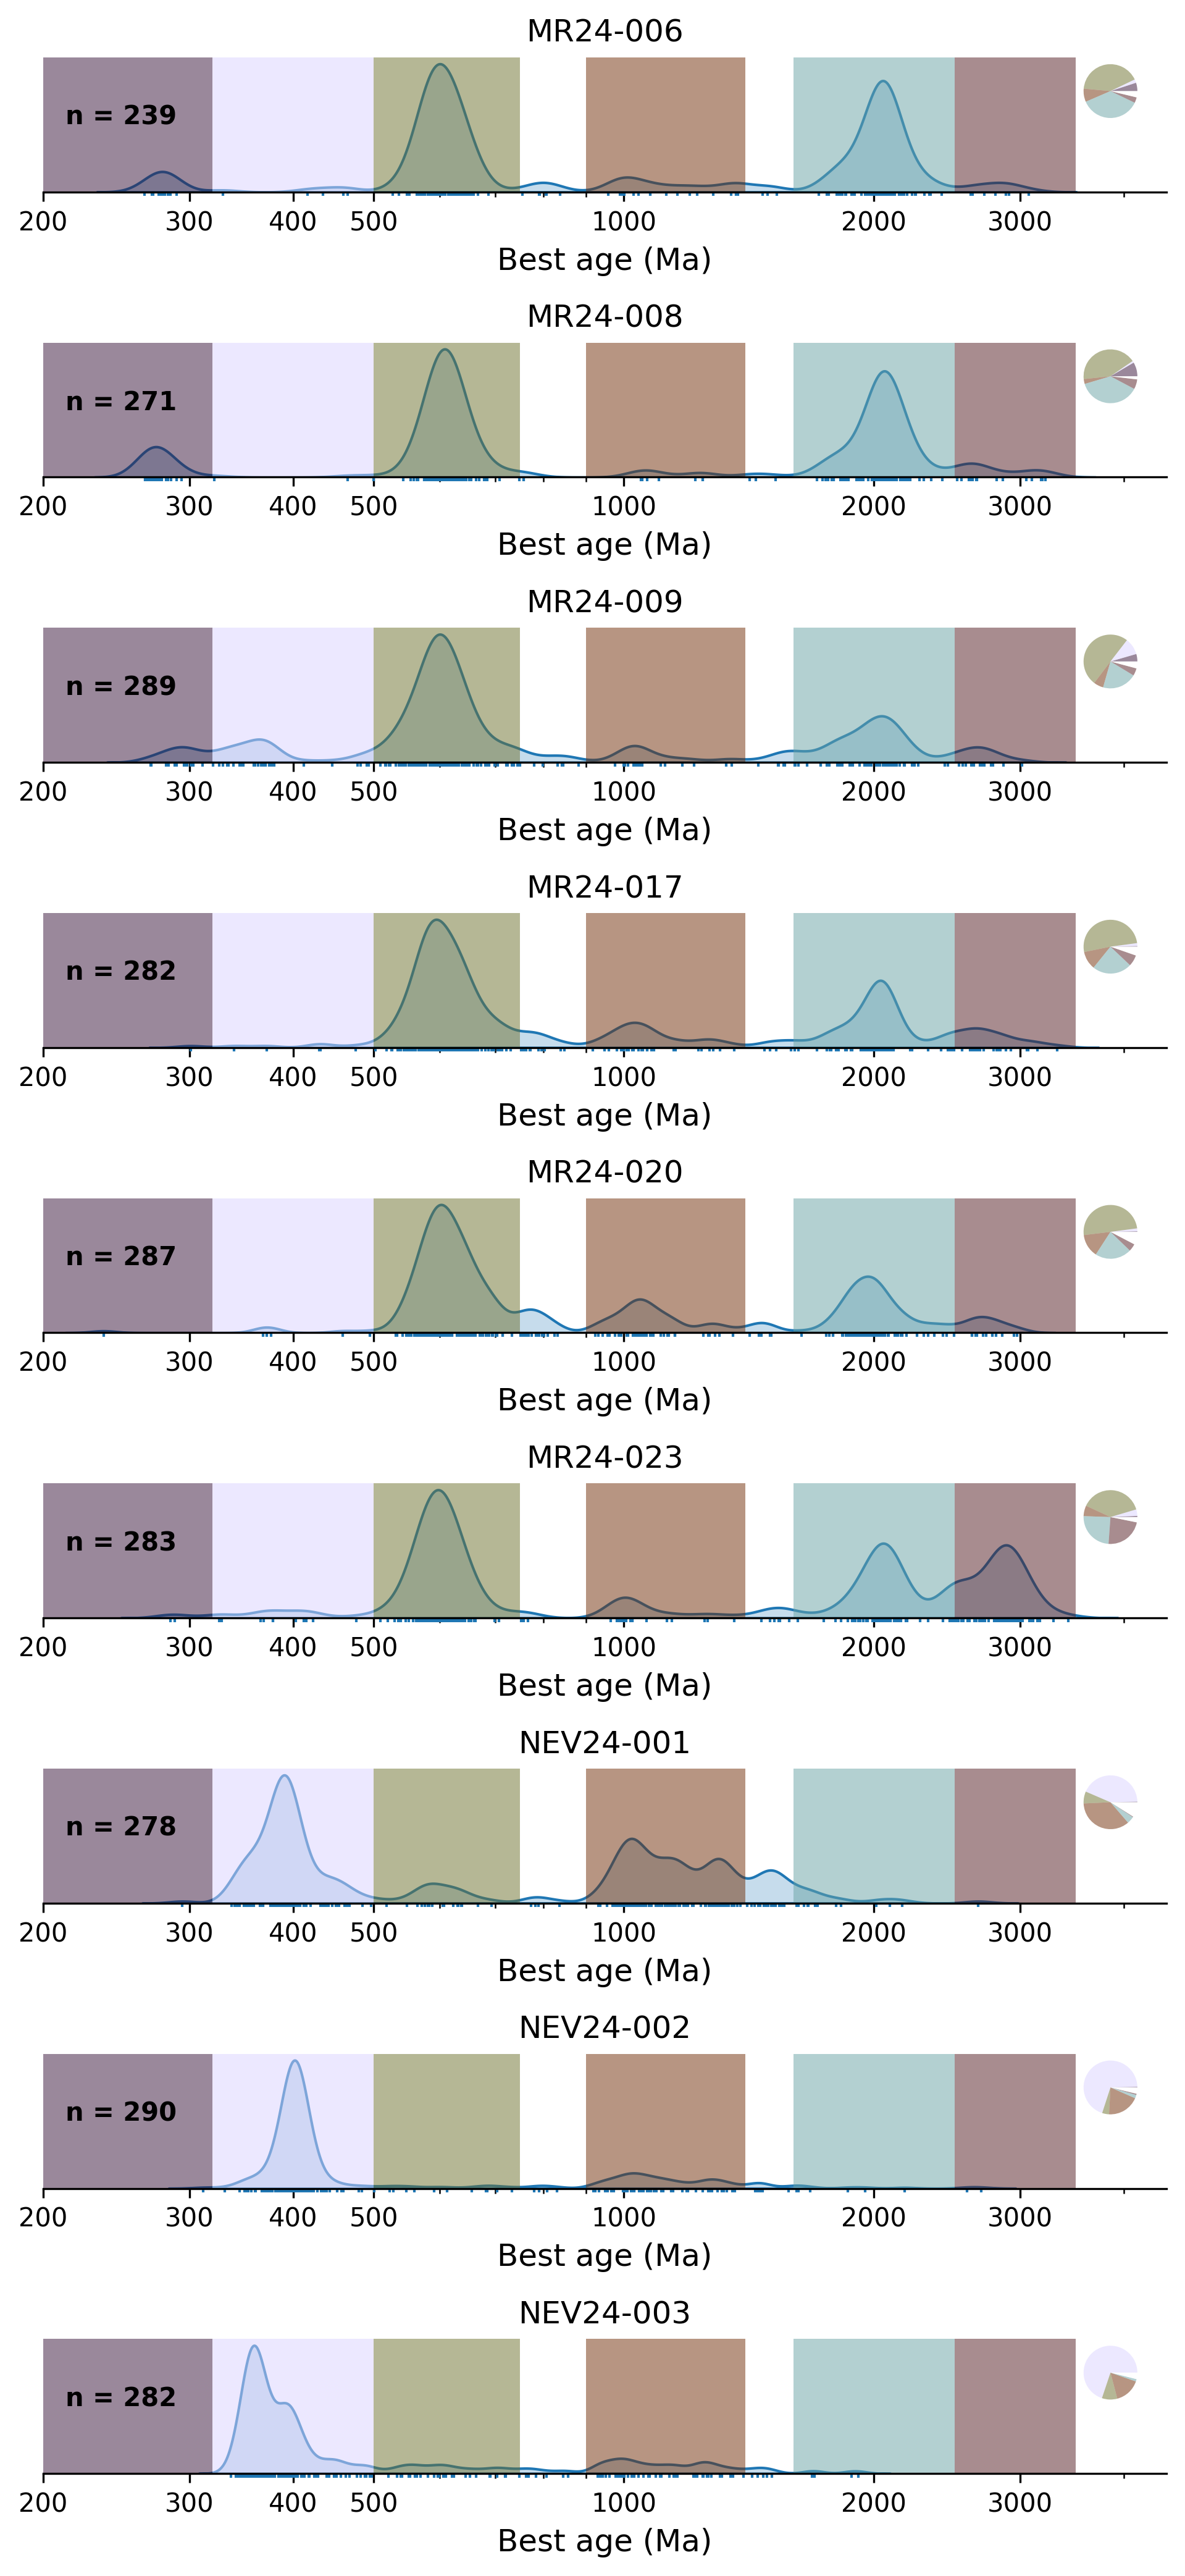

In [39]:
# Plot KDEs using existing best ages (not calculated)
fig,axs = plt.subplots(9,figsize=(6.5,14),dpi=300)

for k,smp in enumerate(smps):
    ax = axs[k]
    smp.kde(ax=ax,bw_adjust=0.2,add_pie=True,spans=spans,span_colors=colors)
    ax.set_xlim(200,4500)
    ax.set_title(smp.name)

plt.tight_layout()
fig.savefig('kdes.pdf')